#### **Лабораторная работа #2**

Выполнил: Мирасов Константин Владимирович

ИСУ: 466716

Группа: J3212

Вариант: 13

#### Постановка задачи

Рассматривается задача Коши для уравнения второго порядка:  
$F(x, y, y', y'') = 0, \quad y(x_0)=y_0, \quad y'(x_0)=y'_0$

Задано уравнение $y y'' = (y')^2 \left(y^2 y' + 1\right)$ с начальными условиями $y(0)=1$, $y'(0)=-3$

Численное решение выполняется на отрезке $x \in [0, 0.08]$. Количество шагов: $n = 40$, поэтому постоянный шаг интегрирования равен $h = \frac{0.08 - 0}{40} = 0.002$

Уравнение второго порядка сведём к системе первого порядка. Для этого введём функции $u_1 = y$, $u_2 = y'$

Тогда исходная задача принимает вид системы:

$\begin{cases}
u_1' = u_2, \\
u_2' = \dfrac{u_2^2 \left(u_1^2 u_2 + 1\right)}{u_1},
\end{cases}
\quad
u_1(0)=1, \quad u_2(0)=-3$

#### Импортируем библиотеки, объявляем необходимые константы и вспомогательные функции

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from typing import Callable
from numpy.typing import NDArray

In [2]:
VARIANT_NUMBER: int = 13
X_START: float = 0.0
Y_START: float = 1.0
FIRST_DERIVATIVE_START: float = -3.0
X_END: float = 0.08
STEP_COUNT: int = 40
STEP_SIZE: float = (X_END - X_START) / STEP_COUNT

#### Аналитическое решение задачи

Рассмотрим задачу Коши: $y y'' = (y')^2 \left(y^2 y' + 1\right), \quad y(0)=1, \quad y'(0)=-3$

Так как уравнение явно не содержит $x$, введём обозначение $p = y'$. Тогда вторую производную можно записать как $y'' = p\frac{dp}{dy}$

Подставим это в исходное уравнение: $y p\frac{dp}{dy} = p^2\left(y^2p + 1\right)$. Поскольку в начальной точке $p(1)=y'(0)=-3 \ne 0$, делим уравнение на $p$ и получаем $\frac{dp}{dy} = \frac{p}{y} + yp^2$

Введём замену $u = \frac{1}{p}$. Тогда уравнение принимает линейный вид: $\frac{du}{dy} + \frac{u}{y} = -y$

Интегрирующий множитель равен $\mu(y)=e^{\int \frac{1}{y}\,dy}=y$. Умножая уравнение на $y$, получаем $(yu)' = -y^2$

После интегрирования имеем $yu = -\frac{y^3}{3} + C$, откуда $u = \frac{C}{y} - \frac{y^2}{3}$

Так как $u = \frac{1}{p} = \frac{dx}{dy}$, используем начальные условия $y(0)=1$ и $y'(0)=-3$: $u(1)=\frac{1}{-3}=-\frac{1}{3}$

Подставляя это значение в найденное выражение для $u$, получаем $-\frac{1}{3}=C-\frac{1}{3}$, следовательно, $C=0$

Значит, $\frac{dx}{dy} = -\frac{y^2}{3}$. Интегрируя, получаем $x = -\frac{y^3}{9} + C_1$

Из условия $y(0)=1$ находим $0=-\frac{1}{9}+C_1$, поэтому $C_1=\frac{1}{9}$

Следовательно, $x = \frac{1-y^3}{9}$

Итоговое аналитическое решение имеет вид: $\varphi(x)=\sqrt[3]{1-9x}$

In [3]:
def exact_solution(x_value: float) -> float:
    return float((1 - 9 * x_value) ** (1 / 3))

#### Правая часть дифференциального уравнения и построение равномерной сетки

Интегрирование проводится с постоянным шагом $h$

Узлы равномерной сетки задаются формулой $x_k = x_0 + kh$

In [4]:
def build_grid(x_start: float, x_end: float, step_count: int) -> NDArray[np.float64]:
    return np.linspace(x_start, x_end, step_count + 1)

#### Сведение уравнения второго порядка к системе первого порядка

Для применения метода Рунге-Кутты 4-го порядка введём новые переменные: $z_1 = y$, $z_2 = y'$

Тогда $z_1' = z_2$. Из исходного уравнения $y y'' = (y')^2 \left(y^2 y' + 1\right)$ выразим вторую производную:

$y'' = \frac{(y')^2 \left(y^2 y' + 1\right)}{y}$

С учётом введённых обозначений получаем:

$z_2' = \frac{z_2^2 \left(z_1^2 z_2 + 1\right)}{z_1}$

Таким образом, исходное уравнение второго порядка сводится к системе:

$\begin{cases}
z_1' = z_2, \\
z_2' = \dfrac{z_2^2 \left(z_1^2 z_2 + 1\right)}{z_1}
\end{cases}$

In [5]:
def system_derivative(
    x_value: float,
    state_values: NDArray[np.float64],
) -> NDArray[np.float64]:
    y_value: np.float64 = state_values[0]
    first_derivative_value: np.float64 = state_values[1]
    second_derivative_value: np.float64 = (
        first_derivative_value ** 2
        * (y_value ** 2 * first_derivative_value + 1)
        / y_value
    )

    return np.array([first_derivative_value, second_derivative_value], dtype=float)

#### Метод Рунге-Кутты 4-го порядка для системы первого порядка

Теперь метод Рунге-Кутты 4-го порядка применяется не к одному значению $y$, а к вектору состояния $s = [y, y']$. Поэтому на каждом шаге вычисляются векторные наклоны, а новое состояние содержит сразу приближения для $y$ и $y'$

$
k_1 = f(x_k, s_k)
$

$
k_2 = f\left(x_k + \frac{h}{2}, s_k + \frac{h k_1}{2}\right)
$

$
k_3 = f\left(x_k + \frac{h}{2}, s_k + \frac{h k_2}{2}\right)
$

$
k_4 = f(x_k + h, s_k + h k_3)
$

$
s_{k+1} = s_k + \frac{h}{6}(k_1 + 2k_2 + 2k_3 + k_4)
$

In [6]:
def solve_runge_kutta_4_system(
    system_function: Callable[[float, NDArray[np.float64]], NDArray[np.float64]],
    x_values: NDArray[np.float64],
    initial_state: NDArray[np.float64],
) -> NDArray[np.float64]:
    state_values: NDArray[np.float64] = np.zeros(
        (len(x_values), len(initial_state)),
        dtype=np.float64,
    )
    state_values[0] = initial_state

    for index in range(len(x_values) - 1):
        current_x: float = x_values[index]
        current_state: NDArray[np.float64] = state_values[index]
        step_size: float = x_values[index + 1] - x_values[index]

        slope_1: NDArray[np.float64] = system_function(current_x, current_state)
        slope_2: NDArray[np.float64] = system_function(
            current_x + step_size / 2,
            current_state + step_size * slope_1 / 2,
        )
        slope_3: NDArray[np.float64] = system_function(
            current_x + step_size / 2,
            current_state + step_size * slope_2 / 2,
        )
        slope_4: NDArray[np.float64] = system_function(
            current_x + step_size,
            current_state + step_size * slope_3,
        )

        state_values[index + 1] = current_state + step_size * (
            slope_1 + 2 * slope_2 + 2 * slope_3 + slope_4
        ) / 6

    return state_values

#### Вычисление приближённого и точного решений

Теперь строится равномерная сетка на заданном отрезке, задаётся начальный вектор состояния $s_0 = [y_0, y'_0]$ и вычисляется приближённое решение методом Рунге-Кутты 4-го порядка. После этого отдельно извлекаются приближённые значения $y$ и $y'$, а также вычисляются значения точного решения в узлах сетки

In [7]:
x_start = X_START
x_end = X_END
y_start = Y_START
first_derivative_start = FIRST_DERIVATIVE_START
step_count = STEP_COUNT

x_values = build_grid(x_start, x_end, step_count)

initial_state = np.array([y_start, first_derivative_start], dtype=float)

state_values = solve_runge_kutta_4_system(
    system_derivative,
    x_values,
    initial_state,
)

approximate_y_values = state_values[:, 0]
approximate_first_derivative_values = state_values[:, 1]

exact_values = np.array([exact_solution(x_value) for x_value in x_values], dtype=float)

#### Построение таблицы решений

В таблице сравниваются значения аналитического и приближённого решений в узлах равномерной сетки. Также в таблицу выводится численно найденное значение первой производной $y'$

In [8]:
solution_table = pd.DataFrame({
    "x": x_values,
    "Точное решение": exact_values,
    "Приближённое решение": approximate_y_values,
    "Приближённое значение y'": approximate_first_derivative_values,
})

solution_table

,x,Точное решение,Приближённое решение,Приближённое значение y'
0,0.000,1.000000,1.000000,-3.000000
1,0.002,0.993964,0.993964,-3.036549
2,0.004,0.987853,0.987853,-3.074231
3,0.006,0.981666,0.981666,-3.113105
4,0.008,0.975400,0.975400,-3.153232
5,0.010,0.969052,0.969052,-3.194677
6,0.012,0.962620,0.962620,-3.237512
7,0.014,0.956101,0.956101,-3.281812
8,0.016,0.949492,0.949492,-3.327658
9,0.018,0.942789,0.942789,-3.375141


#### Графики решений

На одном графике сравниваются аналитическое решение $\varphi(x)$ и приближённое решение, полученное методом Рунге-Кутты 4-го порядка

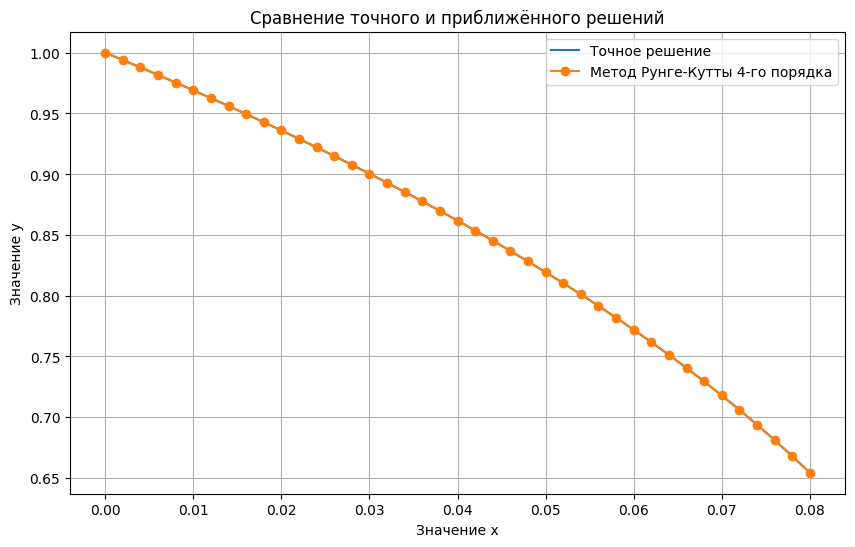

In [9]:
plt.figure(figsize=(10, 6))

plt.plot(x_values, exact_values, label="Точное решение")
plt.plot(x_values, approximate_y_values, marker="o", label="Метод Рунге-Кутты 4-го порядка")

plt.title("Сравнение точного и приближённого решений")
plt.xlabel("Значение x")
plt.ylabel("Значение y")
plt.legend()
plt.grid(True)
plt.show()

#### Вычисление абсолютной и относительной погрешности

В соответствии с заданием абсолютная и относительная погрешности вычисляются по формулам:

$
\Delta = \max_{k \in [1:n]} \left|\varphi(x_k) - \widetilde{\varphi}(x_k)\right|
$

$
\delta = \max_{k \in [1:n]} \frac{\left|\varphi(x_k) - \widetilde{\varphi}(x_k)\right|}{\left|\widetilde{\varphi}(x_k)\right|}
$

Максимум берётся по $k$ от $1$ до $n$, поэтому начальная точка $x_0$ при вычислении погрешностей не учитывается

In [10]:
def calculate_absolute_error(
    exact_values: NDArray[np.float64],
    approximate_values: NDArray[np.float64],
) -> float:
    exact_values_without_initial_point: NDArray[np.float64] = exact_values[1:]
    approximate_values_without_initial_point: NDArray[np.float64] = approximate_values[1:]

    absolute_errors: NDArray[np.float64] = np.abs(
        exact_values_without_initial_point - approximate_values_without_initial_point
    )

    return float(np.max(absolute_errors))


def calculate_relative_error(
    exact_values: NDArray[np.float64],
    approximate_values: NDArray[np.float64],
) -> float:
    exact_values_without_initial_point: NDArray[np.float64] = exact_values[1:]
    approximate_values_without_initial_point: NDArray[np.float64] = approximate_values[1:]

    absolute_errors: NDArray[np.float64] = np.abs(
        exact_values_without_initial_point - approximate_values_without_initial_point
    )
    absolute_approximate_values: NDArray[np.float64] = np.abs(
        approximate_values_without_initial_point
    )

    relative_error_denominators: NDArray[np.float64] = np.where(
        absolute_approximate_values != 0.0,
        absolute_approximate_values,
        np.nan,
    )
    relative_errors: NDArray[np.float64] = absolute_errors / relative_error_denominators

    return float(np.nanmax(relative_errors))

#### Таблица погрешностей

Для приближённого решения методом Рунге-Кутты 4-го порядка вычисляются максимальная абсолютная и максимальная относительная погрешности. Максимальная абсолютная погрешность показывает наибольшее отклонение приближённого решения от точного на узлах сетки, а максимальная относительная погрешность показывает это отклонение относительно приближённого значения

In [11]:
absolute_error = calculate_absolute_error(exact_values, approximate_y_values)
relative_error = calculate_relative_error(exact_values, approximate_y_values)

error_table = pd.DataFrame(
    [
        [
            "Метод Рунге-Кутты 4-го порядка",
            absolute_error,
            relative_error,
        ],
    ],
    columns=["Метод", "Абсолютная погрешность", "Относительная погрешность"],
)

error_table

,Метод,Абсолютная погрешность,Относительная погрешность
0,Метод Рунге-Кутты 4-го порядка,5.142933e-08,7.861247e-08


#### Вывод

В ходе лабораторной работы была решена задача Коши для уравнения второго порядка $y y'' = (y')^2 \left(y^2 y' + 1\right)$ с начальными условиями $y(0)=1$, $y'(0)=-3$. Для применения численного метода исходное уравнение было сведено к системе дифференциальных уравнений первого порядка

Для полученной системы был реализован метод Рунге-Кутты 4-го порядка. Также было найдено аналитическое решение $\varphi(x)=\sqrt[3]{1-9x}$, с которым сравнивались приближённые значения на выбранном отрезке

Были построены графики аналитического и приближённого решений, а также вычислены максимальная абсолютная и максимальная относительная погрешности. По графику и таблице погрешностей видно, что численное решение хорошо согласуется с аналитическим решением на выбранном отрезке

При уменьшении шага интегрирования погрешность уменьшается, что соответствует ожидаемому поведению метода Рунге-Кутты 4-го порядка